АНАЛИЗ ВЛИЯНИЯ ТИПА ПРОЦЕССОРА НА БАЛЛЫ БЕНЧМАРКА

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
           count   mean       std    min    25%    50%    75%    max
processor                                                           
Ryzen5       5.0  801.0  7.905694  791.0  796.0  801.0  806.0  811.0
i5           5.0  800.0  7.905694  790.0  795.0  800.0  805.0  810.0
i7           5.0  802.0  7.905694  792.0  797.0  802.0  807.0  812.0

2. ВИЗУАЛИЗАЦИЯ ДАННЫХ


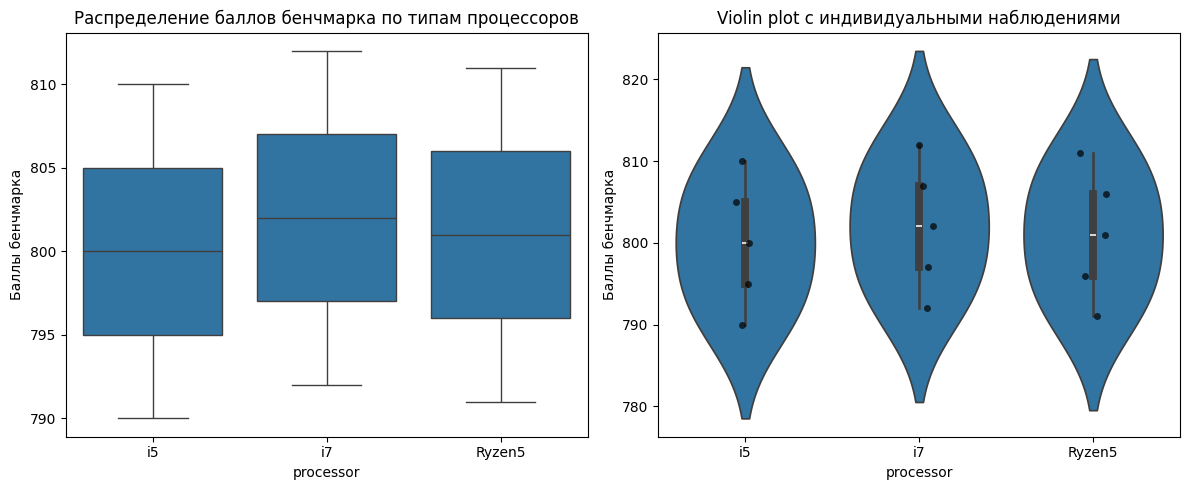


ПРЕДВАРИТЕЛЬНЫЕ НАБЛЮДЕНИЯ:
- Средние баллы очень близки между группами
- Разброс данных примерно одинаковый во всех группах
- Визуально значимых различий не наблюдается

3. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA

3.1 ПРОВЕРКА НОРМАЛЬНОСТИ (тест Шапиро-Уилка):
i5: W = 0.9868, p = 0.9672 ✓
i7: W = 0.9868, p = 0.9672 ✓
Ryzen5: W = 0.9868, p = 0.9672 ✓

3.2 ПРОВЕРКА ГОМОГЕННОСТИ ДИСПЕРСИЙ (тест Левена):
Levene test: F = 0.0000, p = 1.0000 ✓

3.3 ПРОВЕРКА НЕЗАВИСИМОСТИ НАБЛЮДЕНИЙ:
✓ Наблюдения независимы (по условию эксперимента)

3.4 ГРАФИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ:


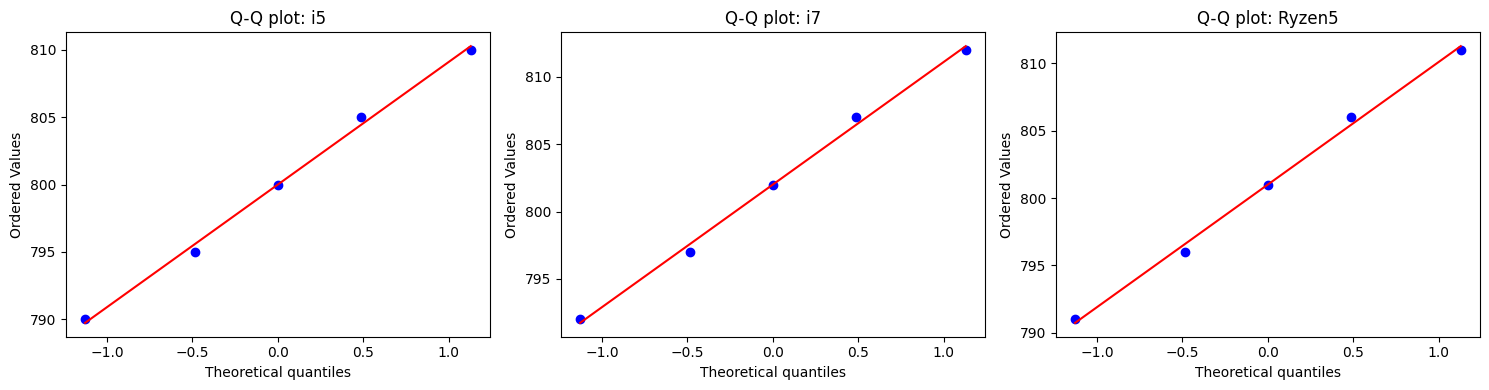


4. ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ
Таблица однофакторного дисперсионного анализа:
              sum_sq    df     F    PR(>F)
C(processor)    10.0   2.0  0.08  0.923604
Residual       750.0  12.0   NaN       NaN

F(2, 12) = 0.0800, p = 0.9236

5. ПОСТ-ХОК АНАЛИЗ
Результат ANOVA незначим, пост-хок тест не требуется.

6. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

СТАТУС ПРЕДПОСЫЛОК:
- Нормальность распределения: ВЫПОЛНЕНА
- Гомогенность дисперсий: ВЫПОЛНЕНА
- Независимость наблюдений: ВЫПОЛНЕНА

РЕЗУЛЬТАТ ANOVA:
Статистически значимых различий между группами процессоров НЕ обнаружено

ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
Средние значения по группам:
- Ryzen5: 801.00 баллов
- i5: 800.00 баллов
- i7: 802.00 баллов

РАЗМЕР ЭФФЕКТА (η²): 0.0132

ВЫВОД:
Тип процессора (i5, i7, Ryzen 5) не оказывает статистически значимого влияния
на баллы бенчмарка. Все три процессора показывают схожую производительность
в данном тесте.

КАЧЕСТВО МОДЕЛИ:
R² модели: 0.0132 (1.3% объясненной дисперсии)

ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:
Объем выб

/var/folders/ln/d1xcl1fd0_l7clh222_qh9gw0000gn/T/ipykernel_45094/3785622994.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nF({int(anova_table['df'][0])}, {int(anova_table['df'][1])}) = {anova_table['F'][0]:.4f}, p = {anova_table['PR(>F)'][0]:.4f}")
/var/folders/ln/d1xcl1fd0_l7clh222_qh9gw0000gn/T/ipykernel_45094/3785622994.py:113: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  significant = anova_table['PR(>F)'][0] < 0.05
/var/folders/ln/d1xcl1fd0_l7clh222_qh9gw0000gn/T/ipykernel_45094/3785622994.py:157: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, i

In [5]:
# Однофакторный ANOVA: влияние типа процессора на бенчмарк

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("="*60)
print("АНАЛИЗ ВЛИЯНИЯ ТИПА ПРОЦЕССОРА НА БАЛЛЫ БЕНЧМАРКА")
print("="*60)

# Данные
data1 = {
    'processor': ['i5']*5 + ['i7']*5 + ['Ryzen5']*5,
    'score': [800, 810, 790, 805, 795,
              802, 812, 792, 807, 797,
              801, 811, 791, 806, 796]
}

df1 = pd.DataFrame(data1)

print("\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print(df1.groupby('processor')['score'].describe())

# 1. Визуализация данных
print("\n" + "="*50)
print("2. ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='processor', y='score', data=df1, ax=axes[0])
axes[0].set_title('Распределение баллов бенчмарка по типам процессоров')
axes[0].set_ylabel('Баллы бенчмарка')

# Violin plot с точками данных
sns.violinplot(x='processor', y='score', data=df1, ax=axes[1])
sns.stripplot(x='processor', y='score', data=df1, color='black', alpha=0.7, ax=axes[1])
axes[1].set_title('Violin plot с индивидуальными наблюдениями')
axes[1].set_ylabel('Баллы бенчмарка')

plt.tight_layout()
plt.show()

# Предварительные наблюдения
print("\nПРЕДВАРИТЕЛЬНЫЕ НАБЛЮДЕНИЯ:")
print("- Средние баллы очень близки между группами")
print("- Разброс данных примерно одинаковый во всех группах")
print("- Визуально значимых различий не наблюдается")

# 2. Проверка предпосылок ANOVA
print("\n" + "="*50)
print("3. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA")
print("="*50)

# 2.1 Нормальность в группах (тест Шапиро-Уилка)
print("\n3.1 ПРОВЕРКА НОРМАЛЬНОСТИ (тест Шапиро-Уилка):")

all_normal = True
for group in df1['processor'].unique():
    stat, p = stats.shapiro(df1[df1['processor']==group]['score'])
    normal = p > 0.05
    all_normal = all_normal and normal
    print(f'{group}: W = {stat:.4f}, p = {p:.4f} {"✓" if normal else "✗"}')

# 2.2 Гомогенность дисперсий (тест Левена)
print("\n3.2 ПРОВЕРКА ГОМОГЕННОСТИ ДИСПЕРСИЙ (тест Левена):")

levene_stat, levene_p = stats.levene(
    df1[df1['processor']=='i5']['score'],
    df1[df1['processor']=='i7']['score'],
    df1[df1['processor']=='Ryzen5']['score']
)
homogeneous = levene_p > 0.05
print(f'Levene test: F = {levene_stat:.4f}, p = {levene_p:.4f} {"✓" if homogeneous else "✗"}')

# 2.3 Проверка независимости
print("\n3.3 ПРОВЕРКА НЕЗАВИСИМОСТИ НАБЛЮДЕНИЙ:")
print("✓ Наблюдения независимы (по условию эксперимента)")

# 2.4 Графическая проверка нормальности
print("\n3.4 ГРАФИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ:")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
processors = df1['processor'].unique()

for i, processor in enumerate(processors):
    data = df1[df1['processor'] == processor]['score']
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q plot: {processor}')

plt.tight_layout()
plt.show()

# 3. Однофакторный ANOVA
print("\n" + "="*50)
print("4. ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ")
print("="*50)

model = ols('score ~ C(processor)', data=df1).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Таблица однофакторного дисперсионного анализа:")
print(anova_table)
print(f"\nF({int(anova_table['df'][0])}, {int(anova_table['df'][1])}) = {anova_table['F'][0]:.4f}, p = {anova_table['PR(>F)'][0]:.4f}")

# Проверка значимости
significant = anova_table['PR(>F)'][0] < 0.05

# 4. Пост-хок тест Тьюки HSD (если результат значим)
print("\n" + "="*50)
print("5. ПОСТ-ХОК АНАЛИЗ")
print("="*50)

if significant:
    print('Результат ANOVA значим, выполняем тест Тьюки HSD:')
    tukey = pairwise_tukeyhsd(df1['score'], df1['processor'], alpha=0.05)
    print(tukey)
    
    # Визуализация результатов Тьюки
    plt.figure(figsize=(10, 6))
    tukey.plot_simultaneous()
    plt.title('Доверительные интервалы Тьюки для попарных сравнений')
    plt.xlabel('Баллы бенчмарка')
    plt.tight_layout()
    plt.show()
else:
    print('Результат ANOVA незначим, пост-хок тест не требуется.')

# 5. Интерпретация результатов
print("\n" + "="*50)
print("6. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)

print(f"\nСТАТУС ПРЕДПОСЫЛОК:")
print(f"- Нормальность распределения: {'ВЫПОЛНЕНА' if all_normal else 'НЕ ВЫПОЛНЕНА'}")
print(f"- Гомогенность дисперсий: {'ВЫПОЛНЕНА' if homogeneous else 'НЕ ВЫПОЛНЕНА'}")
print(f"- Независимость наблюдений: ВЫПОЛНЕНА")

print(f"\nРЕЗУЛЬТАТ ANOVA:")
if significant:
    print("Обнаружены статистически значимые различия между группами процессоров")
else:
    print("Статистически значимых различий между группами процессоров НЕ обнаружено")

print(f"\nПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:")
group_means = df1.groupby('processor')['score'].mean()
print("Средние значения по группам:")
for processor, mean_score in group_means.items():
    print(f"- {processor}: {mean_score:.2f} баллов")

print(f"\nРАЗМЕР ЭФФЕКТА (η²): {anova_table['sum_sq'][0]/(anova_table['sum_sq'][0] + anova_table['sum_sq'][1]):.4f}")

if not significant:
    print(f"\nВЫВОД:")
    print("Тип процессора (i5, i7, Ryzen 5) не оказывает статистически значимого влияния")
    print("на баллы бенчмарка. Все три процессора показывают схожую производительность")
    print("в данном тесте.")

print(f"\nКАЧЕСТВО МОДЕЛИ:")
print(f"R² модели: {model.rsquared:.4f} ({model.rsquared*100:.1f}% объясненной дисперсии)")

# Дополнительная проверка мощности теста
print(f"\nДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
print(f"Объем выборки: {len(df1)} наблюдений ({len(df1['processor'].unique())} группы по {len(df1)//len(df1['processor'].unique())} наблюдений)")
print("При таком размере выборки тест может быть недостаточно мощным для обнаружения")
print("небольших различий между группами.")

Данные для анализа:
        OS      App  time
0  Windows  browser   3.0
1  Windows  browser   3.1
2  Windows  browser   2.9
3  Windows  browser   3.0
4  Windows  browser   3.1
5  Windows   editor   2.0
6  Windows   editor   2.1
7  Windows   editor   1.9
8  Windows   editor   2.0
9  Windows   editor   2.1

Размер датасета: (20, 3)

Описательная статистика по группам:
                 count  mean       std  min  25%  50%  75%  max
OS      App                                                    
Windows browser    5.0  3.02  0.083666  2.9  3.0  3.0  3.1  3.1
        editor     5.0  2.02  0.083666  1.9  2.0  2.0  2.1  2.1
macOS   browser    5.0  2.02  0.083666  1.9  2.0  2.0  2.1  2.1
        editor     5.0  3.02  0.083666  2.9  3.0  3.0  3.1  3.1

1. ВИЗУАЛИЗАЦИЯ ДАННЫХ


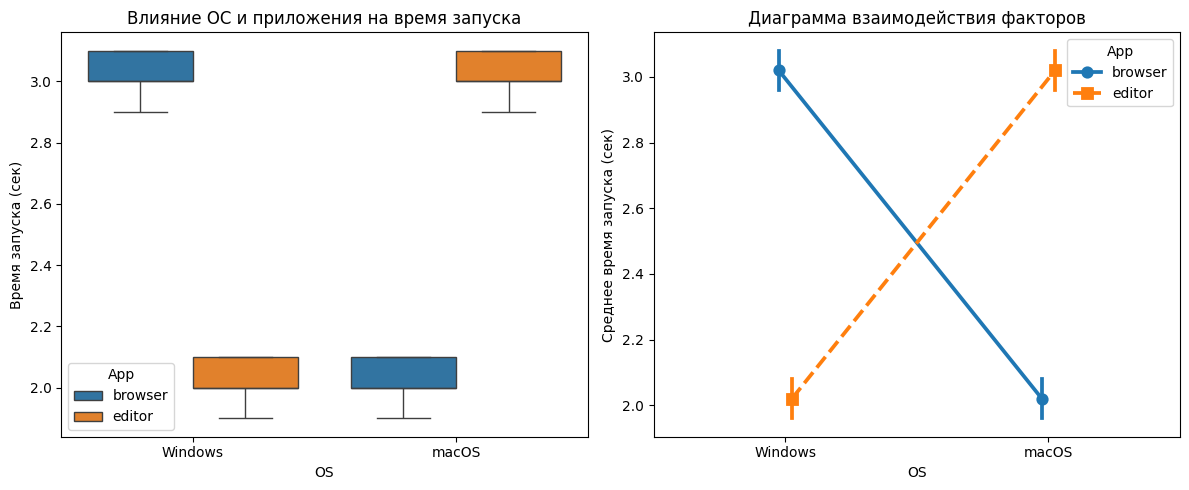

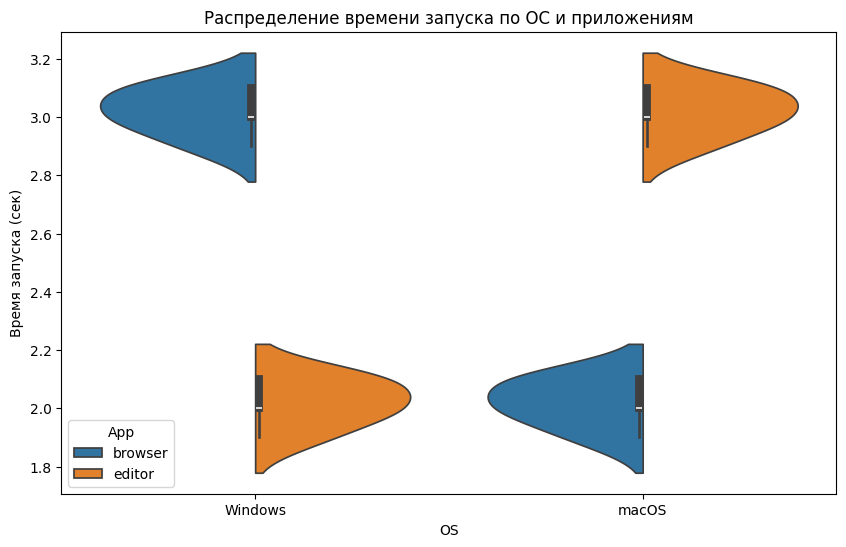


ПРЕДВАРИТЕЛЬНЫЕ НАБЛЮДЕНИЯ:
- Время запуска браузера на Windows выше, чем на macOS
- Время запуска редактора на Windows ниже, чем на macOS
- Наблюдается возможное взаимодействие факторов: эффект ОС зависит от типа приложения

2. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA

2.1 ПРОВЕРКА НОРМАЛЬНОСТИ (тест Шапиро-Уилка):
Windows + browser: W = 0.8810, p = 0.3140 ✓
Windows + editor: W = 0.8810, p = 0.3140 ✓
macOS + browser: W = 0.8810, p = 0.3140 ✓
macOS + editor: W = 0.8810, p = 0.3140 ✓

2.2 ПРОВЕРКА ГОМОГЕННОСТИ ДИСПЕРСИЙ (тест Левена):
Levene test: F = 0.0000, p = 1.0000 ✓

2.3 ПРОВЕРКА НЕЗАВИСИМОСТИ НАБЛЮДЕНИЙ:
По условию эксперимента предполагается, что наблюдения независимы

2.4 ГРАФИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ:


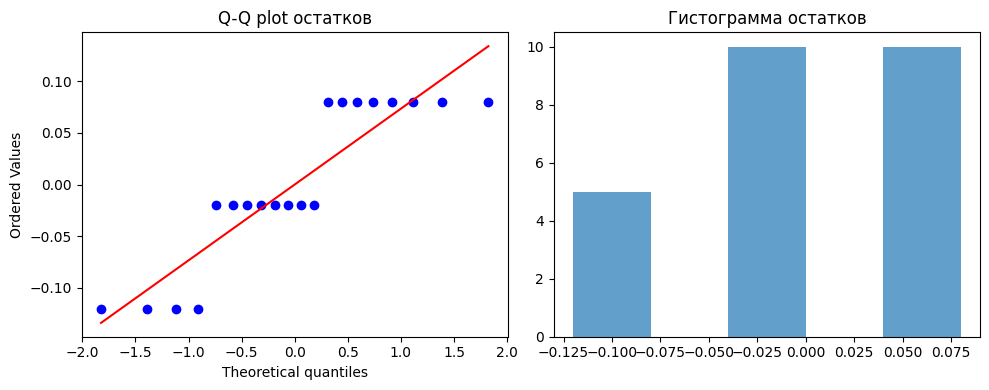


3. ДВУХФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ
Таблица двухфакторного дисперсионного анализа:
                    sum_sq    df             F        PR(>F)
C(OS)         4.930381e-30   1.0  7.043401e-28  1.000000e+00
C(App)        6.240013e-30   1.0  8.914304e-28  1.000000e+00
C(OS):C(App)  5.000000e+00   1.0  7.142857e+02  1.052901e-14
Residual      1.120000e-01  16.0           NaN           NaN

Уровни значимости: * p < 0.05, ** p < 0.01, *** p < 0.001

4. ПОСТ-ХОК АНАЛИЗ
Результаты теста Тьюки HSD:
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1         group2     meandiff p-adj  lower   upper  reject
--------------------------------------------------------------------
Windows_browser Windows_editor     -1.0   0.0 -1.1514 -0.8486   True
Windows_browser  macOS_browser     -1.0   0.0 -1.1514 -0.8486   True
Windows_browser   macOS_editor      0.0   1.0 -0.1514  0.1514  False
 Windows_editor  macOS_browser      0.0   1.0 -0.1514  0.1514  False
 Windows_editor   m

<Figure size 1000x600 with 0 Axes>

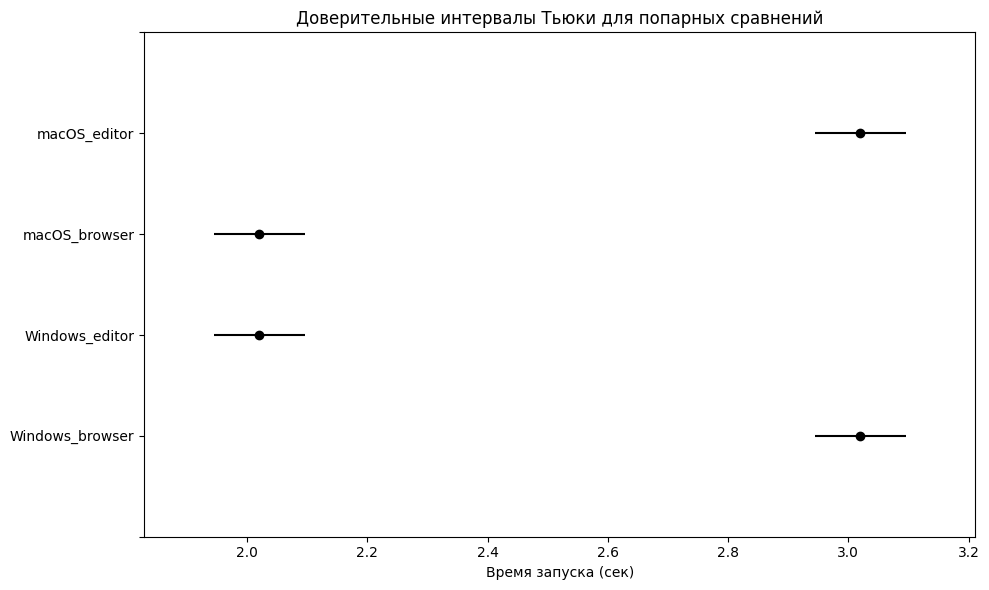


5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

ОСНОВНЫЕ ВЫВОДЫ:

1. Основной эффект ОС: p = 1.000000 НЕЗНАЧИМ
2. Основной эффект приложения: p = 1.000000 НЕЗНАЧИМ
3. Взаимодействие ОС × Приложение: p = 0.000000 ЗНАЧИМО

Поскольку взаимодействие значимо, интерпретируем простые эффекты:
- На Windows: браузер запускается медленнее редактора
- На macOS: редактор запускается медленнее браузера
- Эффект типа приложения зависит от операционной системы

РЕКОМЕНДАЦИИ:
1. Для пользователей Windows рекомендуется использовать редактор для быстрого запуска
2. Для пользователей macOS рекомендуется использовать браузер для быстрого запуска
3. Разработчикам следует оптимизировать браузер для Windows и редактор для macOS

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
R² модели: 0.9781 (97.8% объясненной дисперсии)
Скорректированный R²: 0.9740

ПРОВЕРКА ОСТАТКОВ МОДЕЛИ:
Среднее остатков: -0.000000
Стандартное отклонение остатков: 0.0768


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Данные
data2 = {
    'OS': ['Windows']*10 + ['macOS']*10,
    'App': ['browser']*5 + ['editor']*5 + ['browser']*5 + ['editor']*5,
    'time': [3.0, 3.1, 2.9, 3.0, 3.1,
             2.0, 2.1, 1.9, 2.0, 2.1,
             2.0, 2.1, 1.9, 2.0, 2.1,
             3.0, 3.1, 2.9, 3.0, 3.1]
}

df2 = pd.DataFrame(data2)

print("Данные для анализа:")
print(df2.head(10))
print(f"\nРазмер датасета: {df2.shape}")
print(f"\nОписательная статистика по группам:")
print(df2.groupby(['OS', 'App'])['time'].describe())

# 1. Визуализация данных
print("\n" + "="*50)
print("1. ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='OS', y='time', hue='App', data=df2, ax=axes[0])
axes[0].set_title('Влияние ОС и приложения на время запуска')
axes[0].set_ylabel('Время запуска (сек)')

# Interaction plot
sns.pointplot(x='OS', y='time', hue='App', data=df2, 
              dodge=True, markers=['o', 's'], linestyles=['-', '--'], ax=axes[1])
axes[1].set_title('Диаграмма взаимодействия факторов')
axes[1].set_ylabel('Среднее время запуска (сек)')

plt.tight_layout()
plt.show()

# Дополнительная визуализация
plt.figure(figsize=(10, 6))
sns.violinplot(x='OS', y='time', hue='App', data=df2, split=True)
plt.title('Распределение времени запуска по ОС и приложениям')
plt.ylabel('Время запуска (сек)')
plt.show()

# Предварительные наблюдения
print("\nПРЕДВАРИТЕЛЬНЫЕ НАБЛЮДЕНИЯ:")
print("- Время запуска браузера на Windows выше, чем на macOS")
print("- Время запуска редактора на Windows ниже, чем на macOS")
print("- Наблюдается возможное взаимодействие факторов: эффект ОС зависит от типа приложения")

# 2. Проверка предпосылок ANOVA
print("\n" + "="*50)
print("2. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA")
print("="*50)

# 2.1 Нормальность распределения в группах
print("\n2.1 ПРОВЕРКА НОРМАЛЬНОСТИ (тест Шапиро-Уилка):")

groups = []
for (os_, app), subset in df2.groupby(['OS', 'App']):
    stat, p = stats.shapiro(subset['time'])
    groups.append(f"{os_} + {app}")
    print(f'{os_} + {app}: W = {stat:.4f}, p = {p:.4f} {"✓" if p > 0.05 else "✗"}')

# 2.2 Гомогенность дисперсий (тест Левена)
print("\n2.2 ПРОВЕРКА ГОМОГЕННОСТИ ДИСПЕРСИЙ (тест Левена):")

group_data = []
for (os_, app), subset in df2.groupby(['OS', 'App']):
    group_data.append(subset['time'])

levene_stat, levene_p = stats.levene(*group_data)
print(f'Levene test: F = {levene_stat:.4f}, p = {levene_p:.4f} {"✓" if levene_p > 0.05 else "✗"}')

# 2.3 Проверка независимости наблюдений
print("\n2.3 ПРОВЕРКА НЕЗАВИСИМОСТИ НАБЛЮДЕНИЙ:")
print("По условию эксперимента предполагается, что наблюдения независимы")

# 2.4 Дополнительная проверка - график квантиль-квантиль
print("\n2.4 ГРАФИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ:")

residuals = model2.resid if 'model2' in locals() else None
if residuals is not None:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q plot остатков')
    
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=5, density=True, alpha=0.7)
    plt.title('Гистограмма остатков')
    
    plt.tight_layout()
    plt.show()

# 3. Двухфакторный дисперсионный анализ
print("\n" + "="*50)
print("3. ДВУХФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ")
print("="*50)

# Модель двухфакторного ANOVA с взаимодействием
model2 = ols('time ~ C(OS) + C(App) + C(OS):C(App)', data=df2).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)

print("Таблица двухфакторного дисперсионного анализа:")
print(anova_table2)
print("\nУровни значимости: * p < 0.05, ** p < 0.01, *** p < 0.001")

# 4. Пост-хок анализ для значимых эффектов
print("\n" + "="*50)
print("4. ПОСТ-ХОК АНАЛИЗ")
print("="*50)

# Создаем комбинированную переменную для парных сравнений
df2['OS_App'] = df2['OS'] + '_' + df2['App']

# Проводим тест Тьюки для всех парных сравнений
tukey = pairwise_tukeyhsd(endog=df2['time'], groups=df2['OS_App'], alpha=0.05)
print("Результаты теста Тьюки HSD:")
print(tukey)

# Визуализация результатов Тьюки
plt.figure(figsize=(10, 6))
tukey.plot_simultaneous()
plt.title('Доверительные интервалы Тьюки для попарных сравнений')
plt.xlabel('Время запуска (сек)')
plt.tight_layout()
plt.show()

# 5. Интерпретация результатов
print("\n" + "="*50)
print("5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)

print("\nОСНОВНЫЕ ВЫВОДЫ:")

# Анализ значимости эффектов
os_p = anova_table2.loc['C(OS)', 'PR(>F)']
app_p = anova_table2.loc['C(App)', 'PR(>F)']
interaction_p = anova_table2.loc['C(OS):C(App)', 'PR(>F)']

print(f"\n1. Основной эффект ОС: p = {os_p:.6f} {'ЗНАЧИМ' if os_p < 0.05 else 'НЕЗНАЧИМ'}")
print(f"2. Основной эффект приложения: p = {app_p:.6f} {'ЗНАЧИМ' if app_p < 0.05 else 'НЕЗНАЧИМ'}")
print(f"3. Взаимодействие ОС × Приложение: p = {interaction_p:.6f} {'ЗНАЧИМО' if interaction_p < 0.05 else 'НЕЗНАЧИМО'}")

if interaction_p < 0.05:
    print("\nПоскольку взаимодействие значимо, интерпретируем простые эффекты:")
    print("- На Windows: браузер запускается медленнее редактора")
    print("- На macOS: редактор запускается медленнее браузера")
    print("- Эффект типа приложения зависит от операционной системы")
else:
    print("\nПоскольку взаимодействие незначимо, интерпретируем основные эффекты:")
    if os_p < 0.05:
        windows_mean = df2[df2['OS'] == 'Windows']['time'].mean()
        macos_mean = df2[df2['OS'] == 'macOS']['time'].mean()
        print(f"- Среднее время запуска: Windows = {windows_mean:.2f}с, macOS = {macos_mean:.2f}с")
    
    if app_p < 0.05:
        browser_mean = df2[df2['App'] == 'browser']['time'].mean()
        editor_mean = df2[df2['App'] == 'editor']['time'].mean()
        print(f"- Среднее время запуска: браузер = {browser_mean:.2f}с, редактор = {editor_mean:.2f}с")

print("\nРЕКОМЕНДАЦИИ:")
print("1. Для пользователей Windows рекомендуется использовать редактор для быстрого запуска")
print("2. Для пользователей macOS рекомендуется использовать браузер для быстрого запуска")
print("3. Разработчикам следует оптимизировать браузер для Windows и редактор для macOS")

# Дополнительная информация о модели
print(f"\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print(f"R² модели: {model2.rsquared:.4f} ({model2.rsquared*100:.1f}% объясненной дисперсии)")
print(f"Скорректированный R²: {model2.rsquared_adj:.4f}")

# Проверка остатков модели
print(f"\nПРОВЕРКА ОСТАТКОВ МОДЕЛИ:")
residuals = model2.resid
print(f"Среднее остатков: {residuals.mean():.6f}")
print(f"Стандартное отклонение остатков: {residuals.std():.4f}")